In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
from pathlib import Path
import copy
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from scipy.integrate import solve_ivp

from nilearn.glm.first_level import (
    make_first_level_design_matrix,
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [4]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Proyecto_PINN_HRF"
)

SUBJECT_ID = "100206"

SCENARIO = "motor_rl_m1_left"
TARGET_CONDITION = "rh"

TRAIN_BLOCK = 1
TEST_BLOCK = 2

REAL_MODEL_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / SUBJECT_ID
    / "real_model_inputs"
)

FULL_SIGNAL_PATH = (
    REAL_MODEL_DIR
    / f"{SCENARIO}_full.csv"
)

EVENT_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / SUBJECT_ID
    / "MNINonLinear"
    / "Results"
    / "tfMRI_MOTOR_RL"
    / "EVs"
    / f"{TARGET_CONDITION}.txt"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "real"
    / SUBJECT_ID
    / "pilot"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Señal ajustada:", FULL_SIGNAL_PATH.exists())
print("Eventos:", EVENT_FILE.exists())

Señal ajustada: True
Eventos: True


In [5]:
full_table = pd.read_csv(
    FULL_SIGNAL_PATH
)

event_values = np.loadtxt(
    EVENT_FILE,
    ndmin=2,
)

events = pd.DataFrame(
    {
        "onset_s": event_values[:, 0],
        "duration_s": event_values[:, 1],
        "amplitude": event_values[:, 2],
    }
).sort_values(
    "onset_s"
).reset_index(
    drop=True
)

time_full = full_table[
    "time_s"
].to_numpy(dtype=float)

bold_adjusted = full_table[
    "bold_adjusted_fraction"
].to_numpy(dtype=float)

TR = float(
    np.median(
        np.diff(time_full)
    )
)

print(f"TR: {TR:.3f} s")
display(events)

TR: 0.720 s


,onset_s,duration_s,amplitude
0,86.498,12.0,1.0
1,162.000,12.0,1.0


In [6]:
SECONDS_BEFORE = 8.0
SECONDS_AFTER = 20.0

EVALUATION_START_S = 0.0
EVALUATION_END_S = 24.0

In [7]:
def extraer_ventana_real(
    frame_times: np.ndarray,
    signal: np.ndarray,
    event: pd.Series,
    seconds_before: float,
    seconds_after: float,
) -> dict:
    """
    Extrae una ventana alrededor de un bloque.

    La línea base se estima mediante una recta usando
    exclusivamente los puntos anteriores al estímulo.
    """
    onset_s = float(
        event["onset_s"]
    )

    duration_s = float(
        event["duration_s"]
    )

    start_s = max(
        float(frame_times[0]),
        onset_s - seconds_before,
    )

    end_s = min(
        float(frame_times[-1]),
        onset_s
        + duration_s
        + seconds_after,
    )

    mask = (
        (frame_times >= start_s)
        & (frame_times <= end_s)
    )

    absolute_time = frame_times[
        mask
    ]

    relative_time = (
        absolute_time - onset_s
    )

    model_time = (
        relative_time + seconds_before
    )

    observed_signal = signal[
        mask
    ]

    prestimulus_mask = (
        relative_time < 0.0
    )

    if prestimulus_mask.sum() < 5:
        raise RuntimeError(
            "La ventana contiene pocos puntos preestímulo."
        )

    baseline_coefficients = np.polyfit(
        relative_time[prestimulus_mask],
        observed_signal[prestimulus_mask],
        deg=1,
    )

    baseline = np.polyval(
        baseline_coefficients,
        relative_time,
    )

    response = (
        observed_signal - baseline
    )

    stimulus = (
        (
            relative_time >= 0.0
        )
        & (
            relative_time < duration_s
        )
    ).astype(float)

    evaluation_mask = (
        (relative_time >= EVALUATION_START_S)
        & (relative_time <= EVALUATION_END_S)
    )

    return {
        "absolute_time_s": absolute_time,
        "relative_time_s": relative_time,
        "model_time_s": model_time,
        "observed_fraction": observed_signal,
        "baseline_fraction": baseline,
        "response_fraction": response,
        "stimulus": stimulus,
        "prestimulus_mask": prestimulus_mask,
        "evaluation_mask": evaluation_mask,
        "baseline_slope": float(
            baseline_coefficients[0]
        ),
        "baseline_intercept": float(
            baseline_coefficients[1]
        ),
        "onset_s": onset_s,
        "duration_s": duration_s,
    }

In [8]:
windows = {}

for block_index, event in events.iterrows():
    block_number = block_index + 1

    windows[block_number] = (
        extraer_ventana_real(
            frame_times=time_full,
            signal=bold_adjusted,
            event=event,
            seconds_before=SECONDS_BEFORE,
            seconds_after=SECONDS_AFTER,
        )
    )

    window = windows[block_number]

    print(
        f"Bloque {block_number}: "
        f"{len(window['relative_time_s'])} puntos, "
        f"{window['prestimulus_mask'].sum()} preestímulo."
    )

Bloque 1: 55 puntos, 11 preestímulo.
Bloque 2: 56 puntos, 11 preestímulo.


In [9]:
train_window = windows[
    TRAIN_BLOCK
]

test_window = windows[
    TEST_BLOCK
]

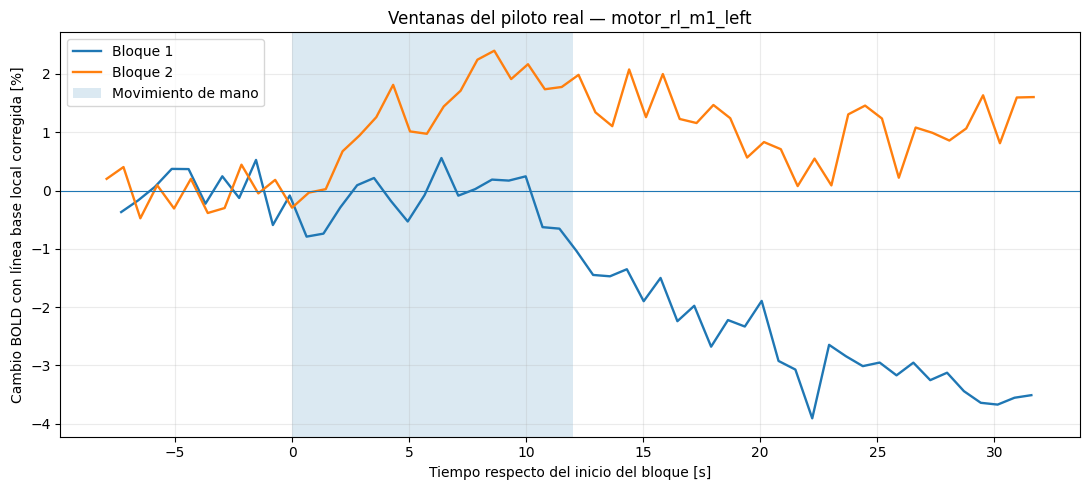

In [10]:
plt.figure(figsize=(11, 5))

for block_number, window in windows.items():
    plt.plot(
        window["relative_time_s"],
        100.0
        * window["response_fraction"],
        linewidth=1.7,
        label=f"Bloque {block_number}",
    )

plt.axvspan(
    0.0,
    float(events.iloc[0]["duration_s"]),
    alpha=0.16,
    label="Movimiento de mano",
)

plt.axhline(
    0.0,
    linewidth=0.8,
)

plt.xlabel(
    "Tiempo respecto del inicio del bloque [s]"
)
plt.ylabel(
    "Cambio BOLD con línea base local corregida [%]"
)
plt.title(
    f"Ventanas del piloto real — {SCENARIO}"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [11]:
def correlacion_segura(
    observed: np.ndarray,
    predicted: np.ndarray,
) -> float:
    observed = np.asarray(
        observed,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    if (
        np.std(observed) < 1e-12
        or np.std(predicted) < 1e-12
    ):
        return np.nan

    return float(
        np.corrcoef(
            observed,
            predicted,
        )[0, 1]
    )

In [12]:
def calcular_metricas(
    observed: np.ndarray,
    predicted: np.ndarray,
) -> dict:
    observed = np.asarray(
        observed,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    mse = mean_squared_error(
        observed,
        predicted,
    )

    return {
        "rmse_percent": float(
            100.0 * np.sqrt(mse)
        ),
        "mae_percent": float(
            100.0
            * mean_absolute_error(
                observed,
                predicted,
            )
        ),
        "r2": float(
            r2_score(
                observed,
                predicted,
            )
        ),
        "pearson_r": correlacion_segura(
            observed,
            predicted,
        ),
    }

In [13]:
def crear_regresor_glm(
    model_times: np.ndarray,
    stimulus_onset_s: float,
    stimulus_duration_s: float,
) -> np.ndarray:
    events_glm = pd.DataFrame(
        {
            "onset": [
                stimulus_onset_s
            ],
            "duration": [
                stimulus_duration_s
            ],
            "trial_type": [
                "stimulus"
            ],
        }
    )

    design = make_first_level_design_matrix(
        frame_times=model_times,
        events=events_glm,
        hrf_model="spm",
        drift_model=None,
        min_onset=-24,
    )

    return design[
        "stimulus"
    ].to_numpy(dtype=float)

In [14]:
stimulus_onset_model_s = (
    SECONDS_BEFORE
)

stimulus_duration_s = float(
    events.iloc[0]["duration_s"]
)

glm_train_regressor = (
    crear_regresor_glm(
        model_times=train_window[
            "model_time_s"
        ],
        stimulus_onset_s=(
            stimulus_onset_model_s
        ),
        stimulus_duration_s=(
            stimulus_duration_s
        ),
    )
)

glm_test_regressor = (
    crear_regresor_glm(
        model_times=test_window[
            "model_time_s"
        ],
        stimulus_onset_s=(
            stimulus_onset_model_s
        ),
        stimulus_duration_s=(
            stimulus_duration_s
        ),
    )
)

In [15]:
glm_denominator = float(
    np.dot(
        glm_train_regressor,
        glm_train_regressor,
    )
)

if glm_denominator < 1e-12:
    raise RuntimeError(
        "El regresor GLM tiene variabilidad insuficiente."
    )

glm_beta = float(
    np.dot(
        glm_train_regressor,
        train_window[
            "response_fraction"
        ],
    )
    / glm_denominator
)

glm_train_prediction = (
    glm_beta
    * glm_train_regressor
)

glm_test_prediction = (
    glm_beta
    * glm_test_regressor
)

print(
    f"Beta GLM: "
    f"{100.0 * glm_beta:.4f} % BOLD"
)

Beta GLM: -0.6095 % BOLD


In [16]:
MLP_MAXIMUM_LAG_S = 24.0

N_LAGS = int(
    round(
        MLP_MAXIMUM_LAG_S
        / TR
    )
) + 1

print("Retardos utilizados:", N_LAGS)

Retardos utilizados: 34


In [17]:
def construir_retardos(
    stimulus: np.ndarray,
    n_lags: int,
) -> np.ndarray:
    stimulus = np.asarray(
        stimulus,
        dtype=float,
    )

    matrix = np.zeros(
        (
            len(stimulus),
            n_lags,
        ),
        dtype=float,
    )

    for lag in range(n_lags):
        if lag == 0:
            matrix[:, lag] = stimulus
        else:
            matrix[lag:, lag] = (
                stimulus[:-lag]
            )

    return matrix

In [18]:
x_train_mlp = construir_retardos(
    train_window["stimulus"],
    N_LAGS,
)

x_test_mlp = construir_retardos(
    test_window["stimulus"],
    N_LAGS,
)

y_train_mlp = (
    100.0
    * train_window[
        "response_fraction"
    ]
)

In [19]:
RANDOM_SEED = 20260717

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        RANDOM_SEED
    )

torch.use_deterministic_algorithms(
    True,
    warn_only=True,
)

torch.set_default_dtype(
    torch.float64
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo:", DEVICE)

Dispositivo: cpu


In [20]:
class RealStimulusMLP(nn.Module):

    def __init__(
        self,
        input_dimension: int,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dimension,
                32,
            ),
            nn.Tanh(),
            nn.Linear(
                32,
                16,
            ),
            nn.Tanh(),
            nn.Linear(
                16,
                1,
            ),
        )

    def forward(
        self,
        inputs: torch.Tensor,
    ):
        return self.network(inputs)

In [21]:
def entrenar_mlp_real(
    x_train: np.ndarray,
    y_train_percent: np.ndarray,
    relative_time_s: np.ndarray,
) -> dict:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)

    n_points = len(x_train)

    rng = np.random.default_rng(
        RANDOM_SEED
    )

    shuffled_indices = rng.permutation(
        n_points
    )

    n_validation = max(
        5,
        int(
            round(
                0.20 * n_points
            )
        ),
    )

    validation_indices = (
        shuffled_indices[
            :n_validation
        ]
    )

    fitting_indices = (
        shuffled_indices[
            n_validation:
        ]
    )

    x_mean = np.mean(
        x_train,
        axis=0,
        keepdims=True,
    )

    x_std = np.std(
        x_train,
        axis=0,
        ddof=0,
        keepdims=True,
    )

    x_std = np.where(
        x_std < 1e-8,
        1.0,
        x_std,
    )

    y_mean = float(
        np.mean(
            y_train_percent
        )
    )

    y_std = float(
        np.std(
            y_train_percent,
            ddof=0,
        )
    )

    if y_std < 1e-8:
        y_std = 1.0

    x_scaled = (
        x_train - x_mean
    ) / x_std

    y_scaled = (
        y_train_percent - y_mean
    ) / y_std

    sample_weights = np.ones(
        n_points,
        dtype=float,
    )

    active_mask = (
        (relative_time_s >= 0.0)
        & (
            relative_time_s <= 24.0
        )
    )

    sample_weights[
        active_mask
    ] = 3.0

    x_tensor = torch.tensor(
        x_scaled,
        device=DEVICE,
    )

    y_tensor = torch.tensor(
        y_scaled[:, None],
        device=DEVICE,
    )

    weights_tensor = torch.tensor(
        sample_weights[:, None],
        device=DEVICE,
    )

    fitting_tensor = torch.tensor(
        fitting_indices,
        dtype=torch.long,
        device=DEVICE,
    )

    validation_tensor = torch.tensor(
        validation_indices,
        dtype=torch.long,
        device=DEVICE,
    )

    model = RealStimulusMLP(
        input_dimension=x_train.shape[1],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-3,
    )

    best_validation_loss = np.inf
    best_state = None
    best_epoch = 0

    epochs_without_improvement = 0
    maximum_epochs = 2500
    patience = 200

    history = []

    for epoch in range(
        1,
        maximum_epochs + 1,
    ):
        model.train()
        optimizer.zero_grad()

        fitting_prediction = model(
            x_tensor[
                fitting_tensor
            ]
        )

        fitting_error = (
            fitting_prediction
            - y_tensor[
                fitting_tensor
            ]
        ) ** 2

        fitting_loss = torch.sum(
            weights_tensor[
                fitting_tensor
            ]
            * fitting_error
        ) / torch.sum(
            weights_tensor[
                fitting_tensor
            ]
        )

        fitting_loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():
            validation_prediction = model(
                x_tensor[
                    validation_tensor
                ]
            )

            validation_loss = torch.mean(
                (
                    validation_prediction
                    - y_tensor[
                        validation_tensor
                    ]
                ) ** 2
            )

        validation_value = float(
            validation_loss.cpu()
        )

        history.append(
            {
                "epoch": epoch,
                "training_loss": float(
                    fitting_loss
                    .detach()
                    .cpu()
                ),
                "validation_loss": (
                    validation_value
                ),
            }
        )

        if (
            validation_value
            < best_validation_loss - 1e-7
        ):
            best_validation_loss = (
                validation_value
            )

            best_state = copy.deepcopy(
                model.state_dict()
            )

            best_epoch = epoch
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= patience
        ):
            break

    if best_state is None:
        raise RuntimeError(
            "La MLP no generó un estado válido."
        )

    model.load_state_dict(
        best_state
    )

    return {
        "model": model,
        "x_mean": x_mean,
        "x_std": x_std,
        "y_mean": y_mean,
        "y_std": y_std,
        "best_epoch": best_epoch,
        "best_validation_loss": (
            best_validation_loss
        ),
        "history": pd.DataFrame(
            history
        ),
    }

In [22]:
mlp_result = entrenar_mlp_real(
    x_train=x_train_mlp,
    y_train_percent=y_train_mlp,
    relative_time_s=train_window[
        "relative_time_s"
    ],
)

print(
    "Mejor época MLP:",
    mlp_result["best_epoch"],
)

Mejor época MLP: 302


In [23]:
def predecir_mlp_real(
    training_result: dict,
    input_matrix: np.ndarray,
    prestimulus_mask: np.ndarray,
) -> np.ndarray:
    input_scaled = (
        input_matrix
        - training_result["x_mean"]
    ) / training_result["x_std"]

    input_tensor = torch.tensor(
        input_scaled,
        device=DEVICE,
    )

    training_result[
        "model"
    ].eval()

    with torch.no_grad():
        prediction_scaled = (
            training_result["model"](
                input_tensor
            )
            .cpu()
            .numpy()
            .reshape(-1)
        )

    prediction_percent = (
        prediction_scaled
        * training_result["y_std"]
        + training_result["y_mean"]
    )

    prediction_percent = (
        prediction_percent
        - np.mean(
            prediction_percent[
                prestimulus_mask
            ]
        )
    )

    return (
        prediction_percent / 100.0
    )

In [24]:
mlp_train_prediction = (
    predecir_mlp_real(
        training_result=mlp_result,
        input_matrix=x_train_mlp,
        prestimulus_mask=train_window[
            "prestimulus_mask"
        ],
    )
)

mlp_test_prediction = (
    predecir_mlp_real(
        training_result=mlp_result,
        input_matrix=x_test_mlp,
        prestimulus_mask=test_window[
            "prestimulus_mask"
        ],
    )
)

In [25]:
PINN_CONFIG = {
    "hidden_layers": [64, 64, 64],
    "phase_1_epochs": 1200,
    "phase_2_epochs": 3500,
    "phase_1_learning_rate": 1e-3,
    "phase_2_network_learning_rate": 3e-4,
    "phase_2_parameter_learning_rate": 8e-4,
    "lambda_data": 1.0,
    "lambda_physics_phase_1": 5.0,
    "lambda_physics_phase_2": 20.0,
    "lambda_initial": 100.0,
    "lambda_terminal": 5.0,
    "n_collocation": 700,
    "residual_scale": 0.05,
    "active_data_weight": 3.0,
    "lbfgs_max_iterations": 300,
}

INITIAL_PARAMETERS = {
    "epsilon": 0.12,
    "tau": 1.20,
    "alpha": 0.38,
}

PARAMETER_BOUNDS = {
    "epsilon": (0.03, 0.35),
    "tau": (0.50, 2.00),
    "alpha": (0.15, 0.60),
}

In [26]:
def logit(
    probability: float,
) -> float:
    probability = np.clip(
        probability,
        1e-8,
        1.0 - 1e-8,
    )

    return float(
        np.log(
            probability
            / (1.0 - probability)
        )
    )

In [27]:
class BoundedScalar(nn.Module):

    def __init__(
        self,
        lower: float,
        upper: float,
        initial: float,
    ):
        super().__init__()

        self.lower = float(lower)
        self.upper = float(upper)

        normalized = (
            (initial - lower)
            / (upper - lower)
        )

        self.raw = nn.Parameter(
            torch.tensor(
                logit(normalized)
            )
        )

    def forward(self):
        return (
            self.lower
            + (
                self.upper
                - self.lower
            )
            * torch.sigmoid(
                self.raw
            )
        )

In [28]:
class RealWindowPINN(nn.Module):

    def __init__(
        self,
        maximum_time_s: float,
    ):
        super().__init__()

        self.maximum_time_s = float(
            maximum_time_s
        )

        dimensions = [
            1,
            *PINN_CONFIG[
                "hidden_layers"
            ],
            4,
        ]

        layers = []

        for input_size, output_size in zip(
            dimensions[:-2],
            dimensions[1:-1],
        ):
            layers.append(
                nn.Linear(
                    input_size,
                    output_size,
                )
            )

            layers.append(
                nn.Tanh()
            )

        layers.append(
            nn.Linear(
                dimensions[-2],
                dimensions[-1],
            )
        )

        self.network = nn.Sequential(
            *layers
        )

        nn.init.zeros_(
            self.network[-1].weight
        )

        nn.init.zeros_(
            self.network[-1].bias
        )

        self.epsilon = BoundedScalar(
            *PARAMETER_BOUNDS[
                "epsilon"
            ],
            INITIAL_PARAMETERS[
                "epsilon"
            ],
        )

        self.tau = BoundedScalar(
            *PARAMETER_BOUNDS["tau"],
            INITIAL_PARAMETERS["tau"],
        )

        self.alpha = BoundedScalar(
            *PARAMETER_BOUNDS["alpha"],
            INITIAL_PARAMETERS["alpha"],
        )

    def states(
        self,
        time_tensor: torch.Tensor,
    ):
        normalized_time = (
            2.0
            * time_tensor
            / self.maximum_time_s
            - 1.0
        )

        raw = self.network(
            normalized_time
        )

        s = (
            0.50
            * torch.tanh(
                raw[:, 0:1]
            )
        )

        f = (
            1.0
            + 0.80
            * torch.tanh(
                raw[:, 1:2]
            )
        )

        v = (
            1.0
            + 0.35
            * torch.tanh(
                raw[:, 2:3]
            )
        )

        q = (
            1.0
            + 0.35
            * torch.tanh(
                raw[:, 3:4]
            )
        )

        return s, f, v, q

    def parameter_values(self):
        return {
            "epsilon": self.epsilon(),
            "tau": self.tau(),
            "alpha": self.alpha(),
        }

    def bold(
        self,
        time_tensor: torch.Tensor,
    ):
        _, _, v, q = self.states(
            time_tensor
        )

        E0 = 0.34
        V0 = 0.02

        k1 = 7.0 * E0
        k2 = 2.0
        k3 = 2.0 * E0 - 0.2

        return V0 * (
            k1 * (1.0 - q)
            + k2 * (
                1.0 - q / v
            )
            + k3 * (
                1.0 - v
            )
        )

In [29]:
PINN_STIMULUS_ONSET = (
    SECONDS_BEFORE
)

PINN_STIMULUS_END = (
    SECONDS_BEFORE
    + stimulus_duration_s
)

In [30]:
def stimulus_torch(
    time_tensor: torch.Tensor,
):
    return (
        (
            time_tensor
            >= PINN_STIMULUS_ONSET
        )
        & (
            time_tensor
            < PINN_STIMULUS_END
        )
    ).to(
        time_tensor.dtype
    )

In [31]:
def time_derivative(
    output: torch.Tensor,
    time_tensor: torch.Tensor,
):
    return torch.autograd.grad(
        outputs=output,
        inputs=time_tensor,
        grad_outputs=torch.ones_like(
            output
        ),
        create_graph=True,
        retain_graph=True,
    )[0]

In [32]:
def physical_residuals(
    model: RealWindowPINN,
    time_tensor: torch.Tensor,
):
    times = (
        time_tensor
        .detach()
        .clone()
        .requires_grad_(True)
    )

    s, f, v, q = model.states(
        times
    )

    ds_dt = time_derivative(
        s,
        times,
    )

    df_dt = time_derivative(
        f,
        times,
    )

    dv_dt = time_derivative(
        v,
        times,
    )

    dq_dt = time_derivative(
        q,
        times,
    )

    parameters = model.parameter_values()

    epsilon = parameters["epsilon"]
    tau = parameters["tau"]
    alpha = parameters["alpha"]

    kappa_s = 0.65
    kappa_f = 0.41
    E0 = 0.34

    neural_input = stimulus_torch(
        times
    )

    extraction = (
        1.0
        - torch.pow(
            torch.tensor(
                1.0 - E0,
                device=DEVICE,
            ),
            1.0 / f,
        )
    )

    return {
        "s": (
            ds_dt
            - (
                epsilon
                * neural_input
                - kappa_s * s
                - kappa_f
                * (f - 1.0)
            )
        ),
        "f": df_dt - s,
        "v": (
            tau * dv_dt
            - (
                f
                - torch.pow(
                    v,
                    1.0 / alpha,
                )
            )
        ),
        "q": (
            tau * dq_dt
            - (
                f * extraction / E0
                - torch.pow(
                    v,
                    1.0 / alpha,
                )
                * q / v
            )
        ),
    }

In [33]:
pinn_observed_time = torch.tensor(
    train_window[
        "model_time_s"
    ][:, None],
    device=DEVICE,
)

pinn_observed_bold = torch.tensor(
    train_window[
        "response_fraction"
    ][:, None],
    device=DEVICE,
)

pinn_data_scale = float(
    np.std(
        train_window[
            "response_fraction"
        ],
        ddof=0,
    )
)

pinn_weights = np.ones(
    len(
        train_window[
            "model_time_s"
        ]
    ),
    dtype=float,
)

pinn_active_mask = (
    (
        train_window[
            "relative_time_s"
        ] >= 0.0
    )
    & (
        train_window[
            "relative_time_s"
        ] <= 24.0
    )
)

pinn_weights[
    pinn_active_mask
] = PINN_CONFIG[
    "active_data_weight"
]

pinn_weight_tensor = torch.tensor(
    pinn_weights[:, None],
    device=DEVICE,
)

In [34]:
collocation_times = np.linspace(
    0.0,
    float(
        train_window[
            "model_time_s"
        ][-1]
    ),
    PINN_CONFIG["n_collocation"],
)

collocation_times = np.unique(
    np.concatenate(
        [
            collocation_times,
            train_window[
                "model_time_s"
            ],
        ]
    )
)

for boundary in [
    PINN_STIMULUS_ONSET,
    PINN_STIMULUS_END,
]:
    collocation_times = (
        collocation_times[
            np.abs(
                collocation_times
                - boundary
            ) > 0.05
        ]
    )

collocation_tensor = torch.tensor(
    collocation_times[:, None],
    device=DEVICE,
)

In [35]:
def calcular_perdidas_pinn(
    model: RealWindowPINN,
    lambda_physics: float,
):
    predicted_bold = model.bold(
        pinn_observed_time
    )

    squared_error = (
        (
            predicted_bold
            - pinn_observed_bold
        )
        / pinn_data_scale
    ) ** 2

    data_loss = torch.sum(
        pinn_weight_tensor
        * squared_error
    ) / torch.sum(
        pinn_weight_tensor
    )

    residuals = physical_residuals(
        model,
        collocation_tensor,
    )

    physics_loss = sum(
        torch.mean(
            (
                residual
                / PINN_CONFIG[
                    "residual_scale"
                ]
            ) ** 2
        )
        for residual in residuals.values()
    )

    initial_time = torch.zeros(
        (1, 1),
        device=DEVICE,
    )

    terminal_time = torch.full(
        (1, 1),
        float(
            train_window[
                "model_time_s"
            ][-1]
        ),
        device=DEVICE,
    )

    s0, f0, v0, q0 = model.states(
        initial_time
    )

    sf, ff, vf, qf = model.states(
        terminal_time
    )

    initial_loss = (
        torch.mean(s0**2)
        + torch.mean(
            (f0 - 1.0) ** 2
        )
        + torch.mean(
            (v0 - 1.0) ** 2
        )
        + torch.mean(
            (q0 - 1.0) ** 2
        )
    )

    terminal_loss = (
        torch.mean(sf**2)
        + torch.mean(
            (ff - 1.0) ** 2
        )
        + torch.mean(
            (vf - 1.0) ** 2
        )
        + torch.mean(
            (qf - 1.0) ** 2
        )
    )

    total_loss = (
        data_loss
        + lambda_physics
        * physics_loss
        + PINN_CONFIG[
            "lambda_initial"
        ]
        * initial_loss
        + PINN_CONFIG[
            "lambda_terminal"
        ]
        * terminal_loss
    )

    return {
        "total": total_loss,
        "data": data_loss,
        "physics": physics_loss,
        "initial": initial_loss,
        "terminal": terminal_loss,
    }

In [36]:
def entrenar_fase_pinn(
    model,
    optimizer,
    n_epochs,
    phase_name,
    lambda_physics,
):
    history = []

    best_loss = np.inf
    best_state = None

    for epoch in range(
        1,
        n_epochs + 1,
    ):
        model.train()
        optimizer.zero_grad()

        losses = calcular_perdidas_pinn(
            model,
            lambda_physics,
        )

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        total_value = float(
            losses["total"]
            .detach()
            .cpu()
        )

        parameter_values = {
            name: float(
                value.detach().cpu()
            )
            for name, value in (
                model.parameter_values()
            ).items()
        }

        history.append(
            {
                "phase": phase_name,
                "epoch": epoch,
                "total_loss": total_value,
                "data_loss": float(
                    losses["data"]
                    .detach()
                    .cpu()
                ),
                "physics_loss": float(
                    losses["physics"]
                    .detach()
                    .cpu()
                ),
                **parameter_values,
            }
        )

        if total_value < best_loss:
            best_loss = total_value
            best_state = copy.deepcopy(
                model.state_dict()
            )

        if (
            epoch == 1
            or epoch % 500 == 0
            or epoch == n_epochs
        ):
            print(
                f"{phase_name} | "
                f"{epoch}/{n_epochs} | "
                f"L={total_value:.5f} | "
                f"Ldata={history[-1]['data_loss']:.5f} | "
                f"Lphys={history[-1]['physics_loss']:.5f} | "
                f"epsilon={parameter_values['epsilon']:.4f} | "
                f"tau={parameter_values['tau']:.4f} | "
                f"alpha={parameter_values['alpha']:.4f}"
            )

    if best_state is None:
        raise RuntimeError(
            "La PINN no produjo un estado válido."
        )

    model.load_state_dict(
        best_state
    )

    return pd.DataFrame(
        history
    )

In [37]:
pinn_model = RealWindowPINN(
    maximum_time_s=float(
        train_window[
            "model_time_s"
        ][-1]
    )
).to(DEVICE)

In [38]:
pinn_model.epsilon.raw.requires_grad_(
    False
)

pinn_model.tau.raw.requires_grad_(
    False
)

pinn_model.alpha.raw.requires_grad_(
    False
)

optimizer_phase_1 = torch.optim.Adam(
    pinn_model.network.parameters(),
    lr=PINN_CONFIG[
        "phase_1_learning_rate"
    ],
)

history_phase_1 = entrenar_fase_pinn(
    model=pinn_model,
    optimizer=optimizer_phase_1,
    n_epochs=PINN_CONFIG[
        "phase_1_epochs"
    ],
    phase_name="network_warmup",
    lambda_physics=PINN_CONFIG[
        "lambda_physics_phase_1"
    ],
)

network_warmup | 1/1200 | L=10.34479 | Ldata=1.66639 | Lphys=1.73568 | epsilon=0.1200 | tau=1.2000 | alpha=0.3800
network_warmup | 500/1200 | L=2.70137 | Ldata=1.86219 | Lphys=0.16591 | epsilon=0.1200 | tau=1.2000 | alpha=0.3800
network_warmup | 1000/1200 | L=2.28684 | Ldata=1.85652 | Lphys=0.08552 | epsilon=0.1200 | tau=1.2000 | alpha=0.3800
network_warmup | 1200/1200 | L=2.25812 | Ldata=1.82177 | Lphys=0.08480 | epsilon=0.1200 | tau=1.2000 | alpha=0.3800


In [39]:
pinn_model.epsilon.raw.requires_grad_(
    True
)

pinn_model.tau.raw.requires_grad_(
    True
)

pinn_model.alpha.raw.requires_grad_(
    True
)

optimizer_phase_2 = torch.optim.Adam(
    [
        {
            "params": (
                pinn_model
                .network
                .parameters()
            ),
            "lr": PINN_CONFIG[
                "phase_2_network_learning_rate"
            ],
        },
        {
            "params": [
                pinn_model.epsilon.raw,
                pinn_model.tau.raw,
                pinn_model.alpha.raw,
            ],
            "lr": PINN_CONFIG[
                "phase_2_parameter_learning_rate"
            ],
        },
    ]
)

history_phase_2 = entrenar_fase_pinn(
    model=pinn_model,
    optimizer=optimizer_phase_2,
    n_epochs=PINN_CONFIG[
        "phase_2_epochs"
    ],
    phase_name="inverse_problem",
    lambda_physics=PINN_CONFIG[
        "lambda_physics_phase_2"
    ],
)

inverse_problem | 1/3500 | L=3.53011 | Ldata=1.82177 | Lphys=0.08480 | epsilon=0.1199 | tau=1.1997 | alpha=0.3801
inverse_problem | 500/3500 | L=2.21699 | Ldata=1.95016 | Lphys=0.01332 | epsilon=0.1004 | tau=1.0657 | alpha=0.3916
inverse_problem | 1000/3500 | L=2.04288 | Ldata=1.88391 | Lphys=0.00794 | epsilon=0.0880 | tau=0.9690 | alpha=0.4049
inverse_problem | 1500/3500 | L=1.94260 | Ldata=1.83586 | Lphys=0.00533 | epsilon=0.0771 | tau=0.8803 | alpha=0.4171
inverse_problem | 2000/3500 | L=1.89202 | Ldata=1.79361 | Lphys=0.00490 | epsilon=0.0697 | tau=0.8189 | alpha=0.4225
inverse_problem | 2500/3500 | L=1.84644 | Ldata=1.76816 | Lphys=0.00390 | epsilon=0.0634 | tau=0.7692 | alpha=0.4282
inverse_problem | 3000/3500 | L=1.81498 | Ldata=1.75218 | Lphys=0.00313 | epsilon=0.0578 | tau=0.7252 | alpha=0.4350
inverse_problem | 3500/3500 | L=1.78368 | Ldata=1.72858 | Lphys=0.00275 | epsilon=0.0529 | tau=0.6864 | alpha=0.4423


In [40]:
lbfgs = torch.optim.LBFGS(
    pinn_model.parameters(),
    lr=0.5,
    max_iter=PINN_CONFIG[
        "lbfgs_max_iterations"
    ],
    history_size=50,
    line_search_fn="strong_wolfe",
)

lbfgs_counter = {
    "count": 0
}

In [41]:
def closure():
    lbfgs.zero_grad()

    losses = calcular_perdidas_pinn(
        pinn_model,
        PINN_CONFIG[
            "lambda_physics_phase_2"
        ],
    )

    losses["total"].backward()

    lbfgs_counter["count"] += 1

    if (
        lbfgs_counter["count"] == 1
        or lbfgs_counter["count"] % 50 == 0
    ):
        parameters = (
            pinn_model.parameter_values()
        )

        print(
            f"LBFGS {lbfgs_counter['count']} | "
            f"L={float(losses['total'].detach().cpu()):.5f} | "
            f"Ldata={float(losses['data'].detach().cpu()):.5f} | "
            f"Lphys={float(losses['physics'].detach().cpu()):.5f} | "
            f"epsilon={float(parameters['epsilon'].detach().cpu()):.4f} | "
            f"tau={float(parameters['tau'].detach().cpu()):.4f} | "
            f"alpha={float(parameters['alpha'].detach().cpu()):.4f}"
        )

    return losses["total"]

In [42]:
_ = lbfgs.step(
    closure
)

LBFGS 1 | L=1.78531 | Ldata=1.72842 | Lphys=0.00284 | epsilon=0.0529 | tau=0.6865 | alpha=0.4423
LBFGS 50 | L=1.77479 | Ldata=1.72990 | Lphys=0.00224 | epsilon=0.0527 | tau=0.6864 | alpha=0.4425
LBFGS 100 | L=1.77169 | Ldata=1.72619 | Lphys=0.00227 | epsilon=0.0517 | tau=0.6858 | alpha=0.4435
LBFGS 150 | L=1.76839 | Ldata=1.72289 | Lphys=0.00227 | epsilon=0.0505 | tau=0.6850 | alpha=0.4449
LBFGS 200 | L=1.76388 | Ldata=1.71809 | Lphys=0.00229 | epsilon=0.0491 | tau=0.6841 | alpha=0.4466
LBFGS 250 | L=1.75493 | Ldata=1.70930 | Lphys=0.00227 | epsilon=0.0461 | tau=0.6818 | alpha=0.4505
LBFGS 300 | L=1.74829 | Ldata=1.70356 | Lphys=0.00223 | epsilon=0.0442 | tau=0.6802 | alpha=0.4534


In [43]:
pinn_parameters = {
    name: float(
        value.detach().cpu()
    )
    for name, value in (
        pinn_model.parameter_values()
    ).items()
}

parameter_table = pd.DataFrame(
    {
        "parameter": [
            "epsilon",
            "tau",
            "alpha",
        ],
        "estimated_value": [
            pinn_parameters["epsilon"],
            pinn_parameters["tau"],
            pinn_parameters["alpha"],
        ],
        "lower_bound": [
            PARAMETER_BOUNDS[
                "epsilon"
            ][0],
            PARAMETER_BOUNDS[
                "tau"
            ][0],
            PARAMETER_BOUNDS[
                "alpha"
            ][0],
        ],
        "upper_bound": [
            PARAMETER_BOUNDS[
                "epsilon"
            ][1],
            PARAMETER_BOUNDS[
                "tau"
            ][1],
            PARAMETER_BOUNDS[
                "alpha"
            ][1],
        ],
    }
)

display(parameter_table)

,parameter,estimated_value,lower_bound,upper_bound
0,epsilon,0.043817,0.03,0.35
1,tau,0.679832,0.50,2.00
2,alpha,0.453990,0.15,0.60


In [44]:
def simular_ode_real(
    model_times: np.ndarray,
    parameters: dict,
    stimulus_onset_s: float,
    stimulus_duration_s: float,
) -> np.ndarray:
    kappa_s = 0.65
    kappa_f = 0.41
    E0 = 0.34
    V0 = 0.02

    k1 = 7.0 * E0
    k2 = 2.0
    k3 = 2.0 * E0 - 0.2

    def stimulus(current_time):
        return float(
            (
                current_time
                >= stimulus_onset_s
            )
            and (
                current_time
                < stimulus_onset_s
                + stimulus_duration_s
            )
        )

    def rhs(
        current_time,
        state,
    ):
        s, f, v, q = state

        f_safe = max(
            float(f),
            1e-8,
        )

        v_safe = max(
            float(v),
            1e-8,
        )

        extraction = (
            1.0
            - (1.0 - E0) ** (
                1.0 / f_safe
            )
        )

        neural_input = stimulus(
            current_time
        )

        return [
            (
                parameters["epsilon"]
                * neural_input
                - kappa_s * s
                - kappa_f
                * (f - 1.0)
            ),
            s,
            (
                f
                - v_safe ** (
                    1.0
                    / parameters["alpha"]
                )
            ) / parameters["tau"],
            (
                f * extraction / E0
                - v_safe ** (
                    1.0
                    / parameters["alpha"]
                )
                * q / v_safe
            ) / parameters["tau"],
        ]

    solution = solve_ivp(
        fun=rhs,
        t_span=(
            float(model_times[0]),
            float(model_times[-1]),
        ),
        y0=[
            0.0,
            1.0,
            1.0,
            1.0,
        ],
        t_eval=model_times,
        max_step=0.02,
        rtol=1e-9,
        atol=1e-11,
    )

    if not solution.success:
        raise RuntimeError(
            solution.message
        )

    _, _, v, q = solution.y

    bold = V0 * (
        k1 * (1.0 - q)
        + k2 * (
            1.0 - q / v
        )
        + k3 * (
            1.0 - v
        )
    )

    return bold

In [45]:
pinn_train_prediction = (
    simular_ode_real(
        model_times=train_window[
            "model_time_s"
        ],
        parameters=pinn_parameters,
        stimulus_onset_s=(
            PINN_STIMULUS_ONSET
        ),
        stimulus_duration_s=(
            stimulus_duration_s
        ),
    )
)

pinn_test_prediction = (
    simular_ode_real(
        model_times=test_window[
            "model_time_s"
        ],
        parameters=pinn_parameters,
        stimulus_onset_s=(
            PINN_STIMULUS_ONSET
        ),
        stimulus_duration_s=(
            stimulus_duration_s
        ),
    )
)

In [46]:
evaluation_mask = (
    test_window[
        "evaluation_mask"
    ]
)

observed_test = (
    test_window[
        "response_fraction"
    ][evaluation_mask]
)

predictions = {
    "GLM": (
        glm_test_prediction[
            evaluation_mask
        ]
    ),
    "MLP": (
        mlp_test_prediction[
            evaluation_mask
        ]
    ),
    "PINN": (
        pinn_test_prediction[
            evaluation_mask
        ]
    ),
}

metric_rows = []

for model_name, prediction in (
    predictions.items()
):
    metric_rows.append(
        {
            "model": model_name,
            **calcular_metricas(
                observed_test,
                prediction,
            ),
        }
    )

pilot_metrics = pd.DataFrame(
    metric_rows
)

display(pilot_metrics)

,model,rmse_percent,mae_percent,r2,pearson_r
0,GLM,1.787857,1.536672,-5.498758,-0.786807
1,MLP,2.916908,2.659116,-16.298576,0.319361
2,PINN,1.141740,1.002821,-1.650324,0.652946


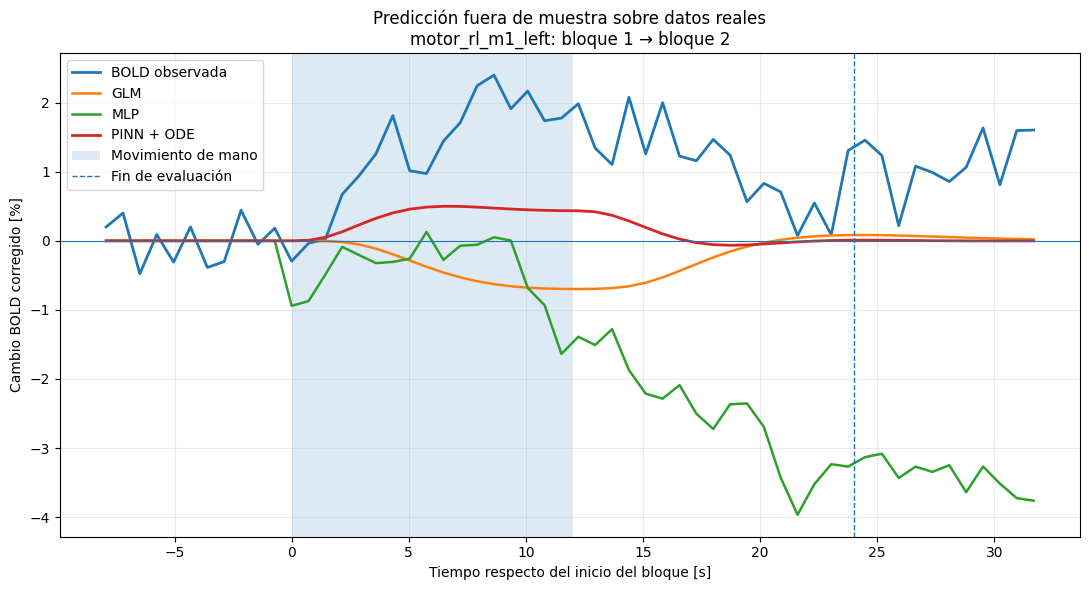

In [47]:
plt.figure(figsize=(11, 6))

plt.plot(
    test_window[
        "relative_time_s"
    ],
    100.0
    * test_window[
        "response_fraction"
    ],
    linewidth=2.0,
    label="BOLD observada",
)

plt.plot(
    test_window[
        "relative_time_s"
    ],
    100.0
    * glm_test_prediction,
    linewidth=1.8,
    label="GLM",
)

plt.plot(
    test_window[
        "relative_time_s"
    ],
    100.0
    * mlp_test_prediction,
    linewidth=1.8,
    label="MLP",
)

plt.plot(
    test_window[
        "relative_time_s"
    ],
    100.0
    * pinn_test_prediction,
    linewidth=2.0,
    label="PINN + ODE",
)

plt.axvspan(
    0.0,
    stimulus_duration_s,
    alpha=0.15,
    label="Movimiento de mano",
)

plt.axhline(
    0.0,
    linewidth=0.8,
)

plt.axvline(
    EVALUATION_END_S,
    linestyle="--",
    linewidth=1.0,
    label="Fin de evaluación",
)

plt.xlabel(
    "Tiempo respecto del inicio del bloque [s]"
)
plt.ylabel(
    "Cambio BOLD corregido [%]"
)

plt.title(
    "Predicción fuera de muestra sobre datos reales\n"
    f"{SCENARIO}: bloque {TRAIN_BLOCK} → bloque {TEST_BLOCK}"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

pilot_figure_path = (
    FIGURES_DIR
    / "real_models_pilot_motor_rl_m1_left_b1_to_b2.png"
)

plt.savefig(
    pilot_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [48]:
prediction_table = pd.DataFrame(
    {
        "relative_time_s": (
            test_window[
                "relative_time_s"
            ]
        ),
        "stimulus": (
            test_window[
                "stimulus"
            ]
        ),
        "observed_fraction": (
            test_window[
                "response_fraction"
            ]
        ),
        "glm_fraction": (
            glm_test_prediction
        ),
        "mlp_fraction": (
            mlp_test_prediction
        ),
        "pinn_fraction": (
            pinn_test_prediction
        ),
        "evaluation_mask": (
            evaluation_mask.astype(int)
        ),
    }
)

prediction_table.to_csv(
    RESULTS_DIR
    / "real_pilot_predictions.csv",
    index=False,
)

pilot_metrics.to_csv(
    RESULTS_DIR
    / "real_pilot_metrics.csv",
    index=False,
)

parameter_table.to_csv(
    RESULTS_DIR
    / "real_pilot_pinn_parameters.csv",
    index=False,
)

pd.concat(
    [
        history_phase_1,
        history_phase_2,
    ],
    ignore_index=True,
).to_csv(
    RESULTS_DIR
    / "real_pilot_pinn_history.csv",
    index=False,
)

mlp_result[
    "history"
].to_csv(
    RESULTS_DIR
    / "real_pilot_mlp_history.csv",
    index=False,
)

print(
    "Resultados guardados en:",
    RESULTS_DIR,
)

Resultados guardados en: /content/drive/MyDrive/Proyecto_PINN_HRF/results/real/100206/pilot
